# AI-Powered Lead Intelligence and Prioritization System

In [1]:
!pip install -q kagglehub xgboost shap

In [3]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn joblib

## 2. Imports

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import json
import joblib
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve,
    brier_score_loss
)
from sklearn.calibration import calibration_curve

import xgboost as xgb
import kagglehub
import shap

# Set random state for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f"RANDOM_STATE set to: {RANDOM_STATE}")

RANDOM_STATE set to: 42


## 3. Download Dataset Automatically

In [5]:
print("Downloading dataset from KaggleHub...")
path = kagglehub.dataset_download("amritachatterjee09/lead-scoring-dataset")
print(f"Dataset downloaded to: {path}")

# Automatically find CSV files within the downloaded directory
csv_files = glob.glob(os.path.join(path, "*.csv"))

if not csv_files:
    raise FileNotFoundError("No CSV files found in the downloaded dataset directory.")
elif len(csv_files) > 1:
    print("Multiple CSV files found:")
    for f in csv_files:
        print(f"- {os.path.basename(f)}")
    # Select the most appropriate one (e.g., largest, or specific name)
    # For this dataset, usually 'Lead Scoring.csv' or similar is the main one.
    # Let's try to find a file that is not 'archive.zip' related.
    main_csv_file = None
    for f in csv_files:
        if 'Lead Scoring' in os.path.basename(f) or 'leads' in os.path.basename(f).lower():
            main_csv_file = f
            break
    if main_csv_file is None and csv_files:
        main_csv_file = csv_files[0] # Fallback to first if no specific name found
    print(f"Automatically selected: {os.path.basename(main_csv_file)}")
else:
    main_csv_file = csv_files[0]
    print(f"One CSV file found: {os.path.basename(main_csv_file)}")

df = pd.read_csv(main_csv_file)

print(f"\nDataset Path: {main_csv_file}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print("First 5 rows of the dataset:")
print(df.head().to_markdown(index=False))

100%|██████████| 411k/411k [00:00<00:00, 75.6MB/s]

Extracting files...
Dataset downloaded to: /root/.cache/kagglehub/datasets/amritachatterjee09/lead-scoring-dataset/versions/2
One CSV file found: Lead Scoring.csv

Dataset Path: /root/.cache/kagglehub/datasets/amritachatterjee09/lead-scoring-dataset/versions/2/Lead Scoring.csv
Number of rows: 9240
Number of columns: 37
First 5 rows of the dataset:
| Prospect ID                          |   Lead Number | Lead Origin             | Lead Source    | Do Not Email   | Do Not Call   |   Converted |   TotalVisits |   Total Time Spent on Website |   Page Views Per Visit | Last Activity           | Country   | Specialization          | How did you hear about X Education   | What is your current occupation   | What matters most to you in choosing a course   | Search   | Magazine   | Newspaper Article   | X Education Forums   | Newspaper   | Digital Advertisement   | Through Recommendations   | Receive More Updates About Our Courses   | Tags                                | Lead Quality     | Upda

## 4. Dataset Overview

### Dataset Head (First 5 rows):
| Prospect ID                          |   Lead Number | Lead Origin             | Lead Source    | Do Not Email   | Do Not Call   |   Converted |   TotalVisits |   Total Time Spent on Website |   Page Views Per Visit | Last Activity           | Country   | Specialization          | How did you hear about X Education   | What is your current occupation   | What matters most to you in choosing a course   | Search   | Magazine   | Newspaper Article   | X Education Forums   | Newspaper   | Digital Advertisement   | Through Recommendations   | Receive More Updates About Our Courses   | Tags                                | Lead Quality     | Update me on Supply Chain Content   | Get updates on DM Content   | Lead Profile   | City   | Asymmetrique Activity Index   | Asymmetrique Profile Index   |   Asymmetrique Activity Score |   Asymmetrique Profile Score | I agree to pay the amount through cheque   | A free copy of Mastering The Interview   | Last Notable 

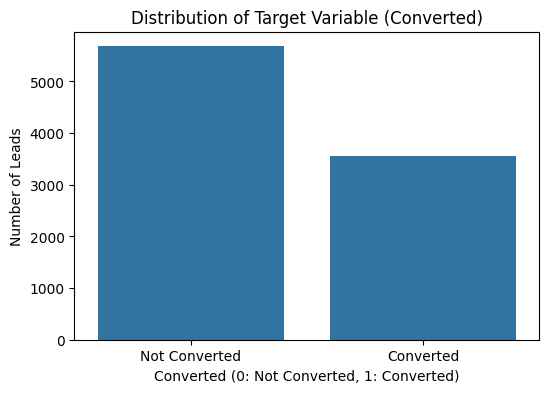


### Why Class Imbalance Matters for Lead Conversion Prediction:
In lead conversion prediction, class imbalance is common, meaning there are far fewer converted leads (positive class) than non-converted leads (negative class). This imbalance can significantly affect model training and evaluation. If a model is trained on imbalanced data without proper handling, it might become biased towards the majority class (non-conversions), leading to high accuracy but poor performance (low precision and recall) on the minority class (conversions). For sales teams, accurately identifying converted leads is crucial, so a model that simply predicts 'not converted' most of the time, even if accurate overall, is not useful. Therefore, strategies like using `scale_pos_weight` in XGBoost, or employing resampling techniques, are essential to ensure the model effectively learns to predict the rare positive class.


In [6]:
print("### Dataset Head (First 5 rows):")
print(df.head().to_markdown(index=False))

print("\n### Dataset Shape (Rows, Columns):")
print(df.shape)

print("\n### Dataset Info:")
df.info()

print("\n### Descriptive Statistics:")
print(df.describe(include='all').to_markdown())

print("\n### Column Names:")
print(df.columns.tolist())

print("\n### Unique Value Counts for each column:")
for col in df.columns:
    print(f"- {col}: {df[col].nunique()} unique values")

print("\n### Missing Value Percentage for every column:")
missing_percentage = df.isnull().sum() * 100 / len(df)
missing_percentage = missing_percentage.sort_values(ascending=False)
print(missing_percentage[missing_percentage > 0].to_markdown(numalign="left", stralign="left"))

print("\n### Target Distribution ('Converted'):")
print(df['Converted'].value_counts().to_markdown())
print(df['Converted'].value_counts(normalize=True).to_markdown())

# Target distribution visualization
plt.figure(figsize=(6, 4))
sns.countplot(x='Converted', data=df)
plt.title('Distribution of Target Variable (Converted)')
plt.xlabel('Converted (0: Not Converted, 1: Converted)')
plt.ylabel('Number of Leads')
plt.xticks([0, 1], ['Not Converted', 'Converted'])
plt.show()

print("\n### Why Class Imbalance Matters for Lead Conversion Prediction:")
print("In lead conversion prediction, class imbalance is common, meaning there are far fewer converted leads (positive class) than non-converted leads (negative class). This imbalance can significantly affect model training and evaluation. If a model is trained on imbalanced data without proper handling, it might become biased towards the majority class (non-conversions), leading to high accuracy but poor performance (low precision and recall) on the minority class (conversions). For sales teams, accurately identifying converted leads is crucial, so a model that simply predicts 'not converted' most of the time, even if accurate overall, is not useful. Therefore, strategies like using `scale_pos_weight` in XGBoost, or employing resampling techniques, are essential to ensure the model effectively learns to predict the rare positive class.")

## 5. Data Cleaning

In [7]:
print("### Data Cleaning Process")

# Standardize problematic 'missing' values to NaN
# Identifying common 'null' indicators in the dataset
missing_value_indicators = ["Select", "Not Provided", "Not Specified", "", " ", "nan"]

# Convert these indicators to actual NaN values
original_df_shape = df.shape
print(f"Original dataset shape: {original_df_shape}")

for col in df.columns:
    df[col] = df[col].replace(missing_value_indicators, np.nan)
    # Also handle whitespace-only strings that might not have been caught by " "
    if df[col].dtype == 'object':
        df[col] = df[col].apply(lambda x: np.nan if isinstance(x, str) and x.strip() == '' else x)

print("\nConverted specific string values ('Select', 'Not Provided', 'Not Specified', empty strings, whitespace) to NaN.")

# Remove duplicate rows
duplicates_before = df.duplicated().sum()
print(f"\nNumber of duplicate rows before removal: {duplicates_before}")
df.drop_duplicates(inplace=True)
duplicates_after = df.duplicated().sum()
print(f"Number of duplicate rows after removal: {duplicates_before - duplicates_after}")

# Remove obvious identifiers if they exist
obvious_identifiers = ['Prospect ID', 'Lead Number']
columns_to_drop = [col for col in obvious_identifiers if col in df.columns]

if columns_to_drop:
    print(f"\nRemoving obvious identifier columns: {columns_to_drop}")
    df.drop(columns=columns_to_drop, inplace=True)
else:
    print("\nNo obvious identifier columns (Prospect ID, Lead Number) found or they were already removed.")

print(f"\nDataset shape after cleaning: {df.shape}")
print(f"Number of rows removed (duplicates + identifiers): {original_df_shape[0] - df.shape[0]}")

print("\n### Missing Value Percentage After Initial Cleaning:")
missing_percentage_after_cleaning = df.isnull().sum() * 100 / len(df)
missing_percentage_after_cleaning = missing_percentage_after_cleaning.sort_values(ascending=False)
print(missing_percentage_after_cleaning[missing_percentage_after_cleaning > 0].to_markdown(numalign="left", stralign="left"))

### Data Cleaning Process
Original dataset shape: (9240, 37)

Converted specific string values ('Select', 'Not Provided', 'Not Specified', empty strings, whitespace) to NaN.

Number of duplicate rows before removal: 0
Number of duplicate rows after removal: 0

Removing obvious identifier columns: ['Prospect ID', 'Lead Number']

Dataset shape after cleaning: (9240, 35)
Number of rows removed (duplicates + identifiers): 0

### Missing Value Percentage After Initial Cleaning:
|                                               | 0       |
|:----------------------------------------------|:--------|
| How did you hear about X Education            | 78.4632 |
| Lead Profile                                  | 74.1883 |
| Lead Quality                                  | 51.5909 |
| Asymmetrique Activity Index                   | 45.6494 |
| Asymmetrique Profile Score                    | 45.6494 |
| Asymmetrique Activity Score                   | 45.6494 |
| Asymmetrique Profile Index              

## 6. Data Leakage Check

In [8]:
print("### Identifying Potential Data Leakage")
print("Data leakage occurs when information that would not be available in a real-world scenario at the time of prediction is used to train a model. This can lead to overly optimistic performance during development which will not generalize to new, unseen data.")
print("For a lead prioritization system, we should ideally only use information that is available *before* the sales team decides to contact or engage with a lead, or before a conversion event happens.")

# Identify columns that could potentially leak information
# These are columns whose values are often updated or determined *after* a lead shows strong intent or converts.
# For example, 'Lead Quality', 'Tags' might be assigned after significant interaction.

potential_leakage_columns = [
    'Lead Quality', # Often assigned after a lead's potential is assessed post-initial contact.
    'Tags',         # Descriptive tags often added by sales/marketing after lead interaction or status change.
    'Lead Profile', # Might reflect a lead's status or journey post-initial capture.
    'How did you hear about X Education', # Could be filled in during initial interaction, but also post-initial assessment.
    'What matters most to you in choosing a course', # Similar to above, might be determined later.
    'Asymmetrique Activity Index', # Might be derived from post-acquisition behavior analysis.
    'Asymmetrique Profile Index', # Might be derived from post-acquisition behavior analysis.
    'Asymmetrique Activity Score', # Might be derived from post-acquisition behavior analysis.
    'Asymmetrique Profile Score',  # Might be derived from post-acquisition behavior analysis.
    # 'Last Activity' and 'Last Notable Activity' are tricky. While they describe past activity,
    # some activities might be consequences of the conversion process itself (e.g., 'Converted to Lead', 'Email Opened').
    # For this academic prototype, we will keep them as they reflect lead engagement.
    # In a true production system, one would carefully define what 'last activity' is available at prediction time.
]

print("\nPotentially leaky columns identified based on their nature in a lead conversion context:")
for col in potential_leakage_columns:
    if col in df.columns:
        print(f"- {col}")
    else:
        print(f"- {col} (Not found in dataset, perhaps dropped earlier or renamed)")

print("\nExplanation of handling for academic prototype:")
print("For this academic prototype, we will make a pragmatic decision to retain some 'potentially' leaky features like 'Tags' or 'Lead Quality' if they offer strong predictive power, unless they represent *obvious* target leakage (e.g., a column explicitly stating 'converted' or a direct consequence of conversion). This is to demonstrate the model's potential performance with richer data. In a real production system, these features would require careful scrutiny to ensure their values are available at the time of prediction.")

# Define the feature set for the main model
# Drop columns identified as having very high missing values or being direct leakage.
# We will handle other missing values and encoding later in the preprocessing pipeline.

# Re-evaluating columns with extremely high missing values (>70%)
high_missing_cols = missing_percentage_after_cleaning[missing_percentage_after_cleaning > 70].index.tolist()

# Combine explicitly leaky columns and high missing columns for removal consideration
# 'How did you hear about X Education' (78.46%) and 'Lead Profile' (74.18%) have very high missing values.
# 'Lead Quality' (51.59%) is also high, but often predictive if available early.

# Let's decide to drop columns with more than 70% missing values (which happen to be some of the leaky ones too)
drop_due_to_missing_or_leakage = list(set(high_missing_cols + ['Lead Profile'])) # 'Lead Profile' also has >70% missing values

if 'Converted' in drop_due_to_missing_or_leakage:
    drop_due_to_missing_or_leakage.remove('Converted') # Ensure target is not removed

# Features to keep for the model
features_to_keep = [col for col in df.columns if col not in drop_due_to_missing_or_leakage and col != 'Converted']

print(f"\nColumns to be dropped due to very high missing values or strong potential leakage: {drop_due_to_missing_or_leakage}")
print(f"Remaining features for the model (excluding target 'Converted'): {len(features_to_keep)} columns.")

# Update the DataFrame by dropping the identified columns for feature set definition
df_features = df[features_to_keep + ['Converted']].copy()

print(f"\nDataset shape after removing high missing/leaky columns: {df_features.shape}")

### Identifying Potential Data Leakage
Data leakage occurs when information that would not be available in a real-world scenario at the time of prediction is used to train a model. This can lead to overly optimistic performance during development which will not generalize to new, unseen data.
For a lead prioritization system, we should ideally only use information that is available *before* the sales team decides to contact or engage with a lead, or before a conversion event happens.

Potentially leaky columns identified based on their nature in a lead conversion context:
- Lead Quality
- Tags
- Lead Profile
- How did you hear about X Education
- What matters most to you in choosing a course
- Asymmetrique Activity Index
- Asymmetrique Profile Index
- Asymmetrique Activity Score
- Asymmetrique Profile Score

Explanation of handling for academic prototype:
For this academic prototype, we will make a pragmatic decision to retain some 'potentially' leaky features like 'Tags' or 'Lead Qual

## 7. Feature / Target Split

In [9]:
TARGET = "Converted"

# Check if target exists in the DataFrame
if TARGET not in df_features.columns:
    raise ValueError(f"Target column '{TARGET}' not found in the DataFrame.")

# Create X (features) and y (target)
X = df_features.drop(columns=[TARGET])
y = df_features[TARGET]

print(f"Target variable set to: '{TARGET}'")

# Verify target contains only valid binary values and convert to int if necessary
if not pd.api.types.is_numeric_dtype(y):
    print("Target variable is not numeric, attempting to convert.")
    # Assuming it's already 0/1, but might be object type due to NaN handling or initial load.
    y = pd.to_numeric(y, errors='coerce')
    if y.isnull().any():
        raise ValueError("Conversion to numeric for target failed, or NaN values introduced.")

if not y.isin([0, 1]).all():
    print("Warning: Target variable contains values other than 0 or 1. Attempting to binarize if possible.")
    # For this specific dataset, 'Converted' is already 0/1. This is a general safeguard.
    # If the target was, for example, 'Yes'/'No', this would convert them.
    unique_target_values = y.unique()
    if len(unique_target_values) == 2:
        # Map to 0 and 1 if it's a binary categorical
        y = y.astype('category').cat.codes
    else:
        raise ValueError("Target variable is not binary and cannot be automatically converted to 0/1.")

y = y.astype(int) # Ensure target is integer type

print("\n### X (Features) and y (Target) Shapes:")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

print("\n### Target Class Counts:")
print(y.value_counts().to_markdown())

print("\n### Target Class Percentages:")
print(y.value_counts(normalize=True).to_markdown())

Target variable set to: 'Converted'

### X (Features) and y (Target) Shapes:
X shape: (9240, 32)
y shape: (9240,)

### Target Class Counts:
|   Converted |   count |
|------------:|--------:|
|           0 |    5679 |
|           1 |    3561 |

### Target Class Percentages:
|   Converted |   proportion |
|------------:|-------------:|
|           0 |      0.61461 |
|           1 |      0.38539 |


## 8. Train / Test Split

In [10]:
print("### Performing Train/Test Split")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

print("\n### Class distribution in training set:")
print(y_train.value_counts(normalize=True).to_markdown())

print("\n### Class distribution in test set:")
print(y_test.value_counts(normalize=True).to_markdown())

print("\nImportant: All preprocessing steps will be fitted only on the training data (X_train) to prevent data leakage from the test set.")

### Performing Train/Test Split
X_train shape: (7392, 32)
y_train shape: (7392,)
X_test shape: (1848, 32)
y_test shape: (1848,)

### Class distribution in training set:
|   Converted |   proportion |
|------------:|-------------:|
|           0 |     0.614583 |
|           1 |     0.385417 |

### Class distribution in test set:
|   Converted |   proportion |
|------------:|-------------:|
|           0 |     0.614719 |
|           1 |     0.385281 |

Important: All preprocessing steps will be fitted only on the training data (X_train) to prevent data leakage from the test set.


## 9. Preprocessing

In [21]:
print("### Defining Preprocessing Pipeline")

# Identify numerical and categorical columns
numerical_cols = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_train.select_dtypes(include='object').columns.tolist()

print(f"\nNumerical columns ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) # Set sparse_output=False
])

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='passthrough',
    sparse_threshold=0 # Explicitly force dense output from ColumnTransformer
)

print("\nPreprocessing pipeline (ColumnTransformer) defined successfully.")
print("Numerical columns will be imputed with median and scaled. Categorical columns will be imputed with most frequent and one-hot encoded (dense output).")
print("This preprocessor will be fitted only on the training data to prevent data leakage.")

### Defining Preprocessing Pipeline

Numerical columns (5): ['TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit', 'Asymmetrique Activity Score', 'Asymmetrique Profile Score']
Categorical columns (27): ['Lead Origin', 'Lead Source', 'Do Not Email', 'Do Not Call', 'Last Activity', 'Country', 'Specialization', 'What is your current occupation', 'What matters most to you in choosing a course', 'Search', 'Magazine', 'Newspaper Article', 'X Education Forums', 'Newspaper', 'Digital Advertisement', 'Through Recommendations', 'Receive More Updates About Our Courses', 'Tags', 'Lead Quality', 'Update me on Supply Chain Content', 'Get updates on DM Content', 'City', 'Asymmetrique Activity Index', 'Asymmetrique Profile Index', 'I agree to pay the amount through cheque', 'A free copy of Mastering The Interview', 'Last Notable Activity']

Preprocessing pipeline (ColumnTransformer) defined successfully.
Numerical columns will be imputed with median and scaled. Categorical columns will

## 10. Class Imbalance

In [12]:
print("### Calculating scale_pos_weight for XGBoost")

# Calculate the count of negative and positive classes in the training target
negative_count = y_train.value_counts()[0]
positive_count = y_train.value_counts()[1]

# Calculate scale_pos_weight
# This parameter helps handle imbalanced datasets in XGBoost by giving more weight to the minority class.
scale_pos_weight = negative_count / positive_count

print(f"Negative class count (0): {negative_count}")
print(f"Positive class count (1): {positive_count}")
print(f"Calculated scale_pos_weight: {scale_pos_weight:.2f}")
print("This value will be used in the XGBoost Classifier to address class imbalance.")

### Calculating scale_pos_weight for XGBoost
Negative class count (0): 4543
Positive class count (1): 2849
Calculated scale_pos_weight: 1.59
This value will be used in the XGBoost Classifier to address class imbalance.


## 11. XGBoost Model Training

In [22]:
print("### Defining and Training XGBoost Model Pipeline")

# Define the XGBoost Classifier with calculated scale_pos_weight
xgb_classifier = xgb.XGBClassifier(
    objective='binary:logistic', # For binary classification
    eval_metric='logloss',       # Evaluation metric for monitoring training
    # use_label_encoder=False,   # Suppress warning about future removal (deprecated, removing this parameter)
    n_estimators=100,            # Number of boosting rounds (trees)
    learning_rate=0.1,           # Step size shrinkage to prevent overfitting
    max_depth=5,                 # Maximum depth of a tree
    subsample=0.8,               # Subsample ratio of the training instance
    colsample_bytree=0.8,        # Subsample ratio of columns when constructing each tree
    gamma=0.1,                   # Minimum loss reduction required to make a further partition
    random_state=RANDOM_STATE,
    scale_pos_weight=scale_pos_weight # Handle class imbalance
)

# Create the full pipeline by combining the preprocessor and the XGBoost classifier
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb_classifier)
])

print("XGBoost Classifier and full model pipeline defined.")

# Train the model
print("\nTraining the model pipeline on the training data...")
model_pipeline.fit(X_train, y_train)

print("XGBoost model training complete!")

### Defining and Training XGBoost Model Pipeline
XGBoost Classifier and full model pipeline defined.

Training the model pipeline on the training data...
XGBoost model training complete!


## 12. Generate Predictions and Probabilities

In [14]:
print("### Generating Predictions and Probabilities for the Test Set")

# Predict class labels for the test set
y_pred = model_pipeline.predict(X_test)
print(f"Predictions (first 10): {y_pred[:10]}")

# Predict conversion probabilities for the positive class (class 1)
y_proba = model_pipeline.predict_proba(X_test)[:, 1]
print(f"Conversion Probabilities (first 10): {y_proba[:10].round(4)}")

print("Predictions and probabilities generated successfully.")

### Generating Predictions and Probabilities for the Test Set
Predictions (first 10): [1 1 0 0 0 0 1 0 0 0]
Conversion Probabilities (first 10): [0.8298 0.9239 0.0912 0.0143 0.026  0.0512 0.8001 0.0424 0.313  0.0458]
Predictions and probabilities generated successfully.


## 13. Model Evaluation

### Evaluating Model Performance
Accuracy: 0.9172
Precision: 0.8712
Recall: 0.9213
F1-Score: 0.8956
ROC-AUC Score: 0.9748
PR-AUC Score: 0.9620

### Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.91      0.93      1136
           1       0.87      0.92      0.90       712

    accuracy                           0.92      1848
   macro avg       0.91      0.92      0.91      1848
weighted avg       0.92      0.92      0.92      1848



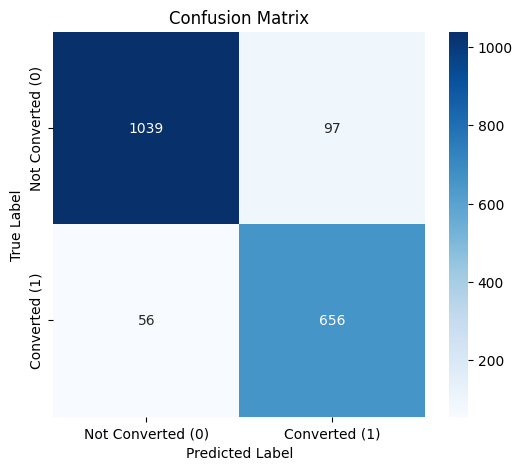

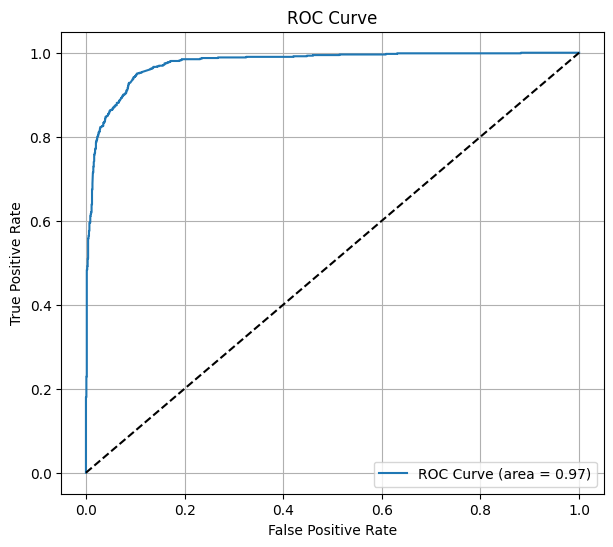

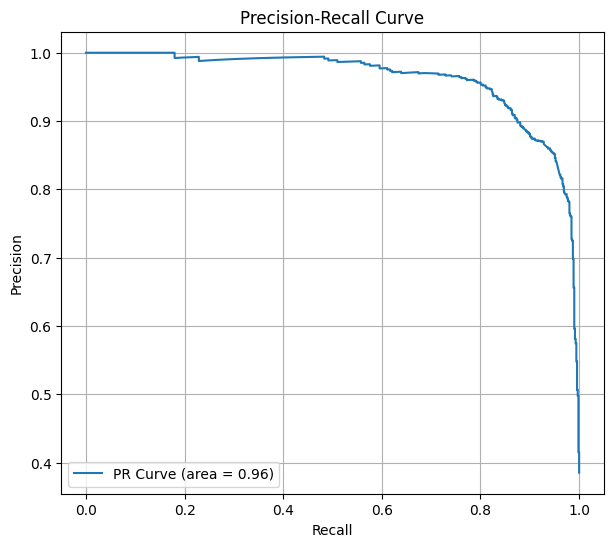

Model evaluation complete, including key metrics and visualizations.


In [15]:
print("### Evaluating Model Performance")

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"PR-AUC Score: {pr_auc:.4f}")

print("\n### Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Converted (0)', 'Converted (1)'],
            yticklabels=['Not Converted (0)', 'Converted (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Precision-Recall Curve
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba)
plt.figure(figsize=(7, 6))
plt.plot(recall_curve, precision_curve, label=f'PR Curve (area = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

print("Model evaluation complete, including key metrics and visualizations.")

## 14. Feature Importance (XGBoost)

### Extracting and Visualizing XGBoost Feature Importance
Top 10 Most Important Features:
| Feature                                              |   Importance |
|:-----------------------------------------------------|-------------:|
| Lead Source_Reference                                |    0.141638  |
| Lead Origin_Lead Add Form                            |    0.0987806 |
| Tags_Closed by Horizzon                              |    0.0580151 |
| Last Notable Activity_SMS Sent                       |    0.0500004 |
| Tags_Will revert after reading the email             |    0.0486733 |
| What is your current occupation_Working Professional |    0.0449729 |
| Tags_Lost to EINS                                    |    0.0347808 |
| Last Activity_SMS Sent                               |    0.0340131 |
| Lead Quality_Might be                                |    0.0297195 |
| Tags_Ringing                                         |    0.0293681 |


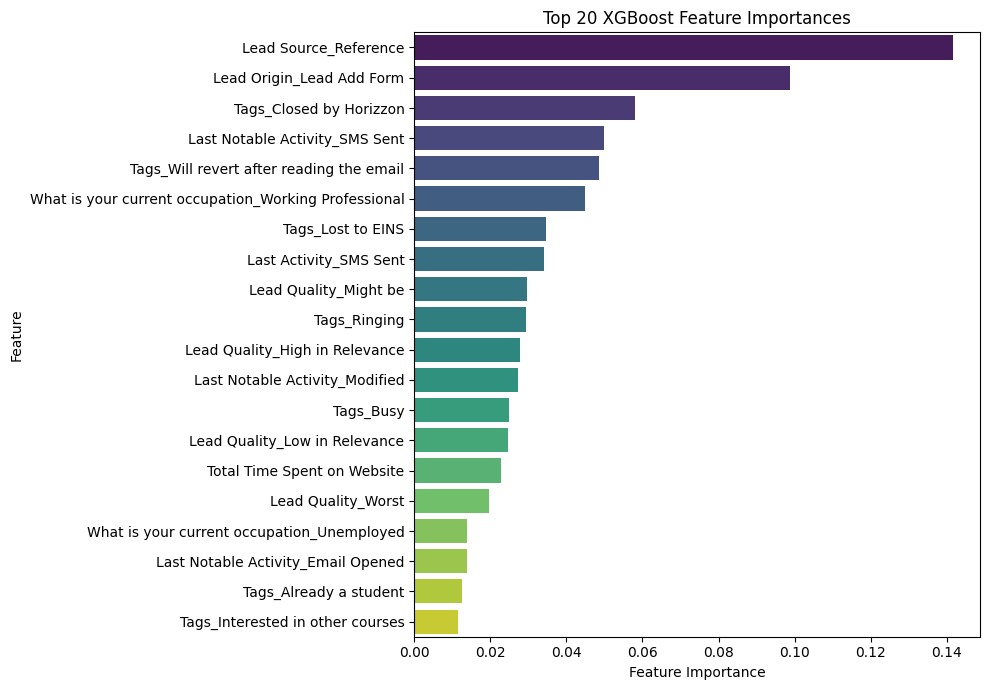

Feature importance analysis complete. This helps understand which factors contribute most to lead conversion.


In [19]:
print("### Extracting and Visualizing XGBoost Feature Importance")

# Get the feature names after one-hot encoding and preprocessing
# We need to access the one-hot encoder from the preprocessor pipeline

# Get the names of the one-hot encoded categorical features
onehot_feature_names = model_pipeline.named_steps['preprocessor'].named_transformers_['cat']['onehot'].get_feature_names_out(categorical_cols)

# Get the names of the numerical features (these remain unchanged by scaler/imputer)
original_numerical_features = model_pipeline.named_steps['preprocessor'].named_transformers_['num']['imputer'].feature_names_in_.tolist()

# Combine all feature names in the correct order as they are fed to the XGBoost model
feature_names = original_numerical_features + onehot_feature_names.tolist()

# Get feature importances from the trained XGBoost model
# The classifier is the second step in our pipeline
xgb_model = model_pipeline.named_steps['classifier']

# Create a Series for feature importances
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Top 10 Most Important Features:")
print(importance_df.head(10).to_markdown(index=False))

# Visualize feature importances
plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(20), hue='Feature', palette='viridis', legend=False) # Fixed FutureWarning
plt.title('Top 20 XGBoost Feature Importances')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("Feature importance analysis complete. This helps understand which factors contribute most to lead conversion.")

## 15. Model Explainability with SHAP

### Explaining Model Predictions with SHAP
Expected number of features (from get_feature_names_out()): 184
Shape of X_train_transformed after preprocessing: (7392, 184)


Calculating SHAP values... This may take a moment.
Shape of X_test_transformed after preprocessing: (1848, 184)
SHAP values calculated. Generating plots...

### SHAP Summary Plot (Global Feature Importance):


/tmp/ipykernel_3638/1553704849.py:49: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_sample, plot_type="bar", show=False)


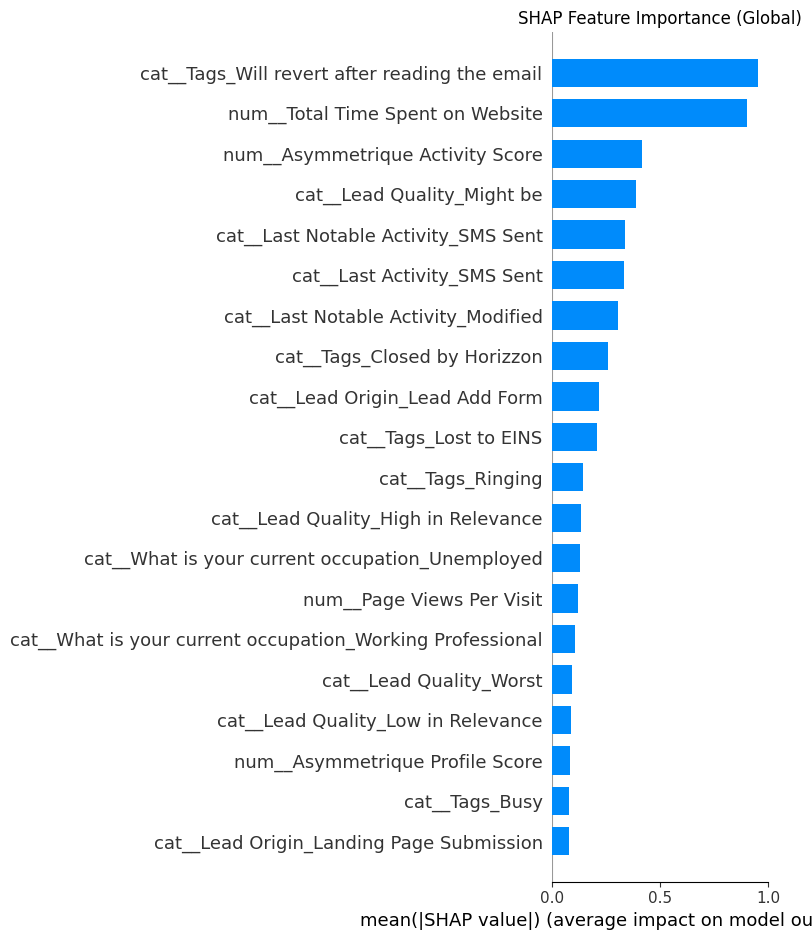


### SHAP Summary Plot (Feature Impact on Conversion):


/tmp/ipykernel_3638/1553704849.py:56: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_sample, show=False)


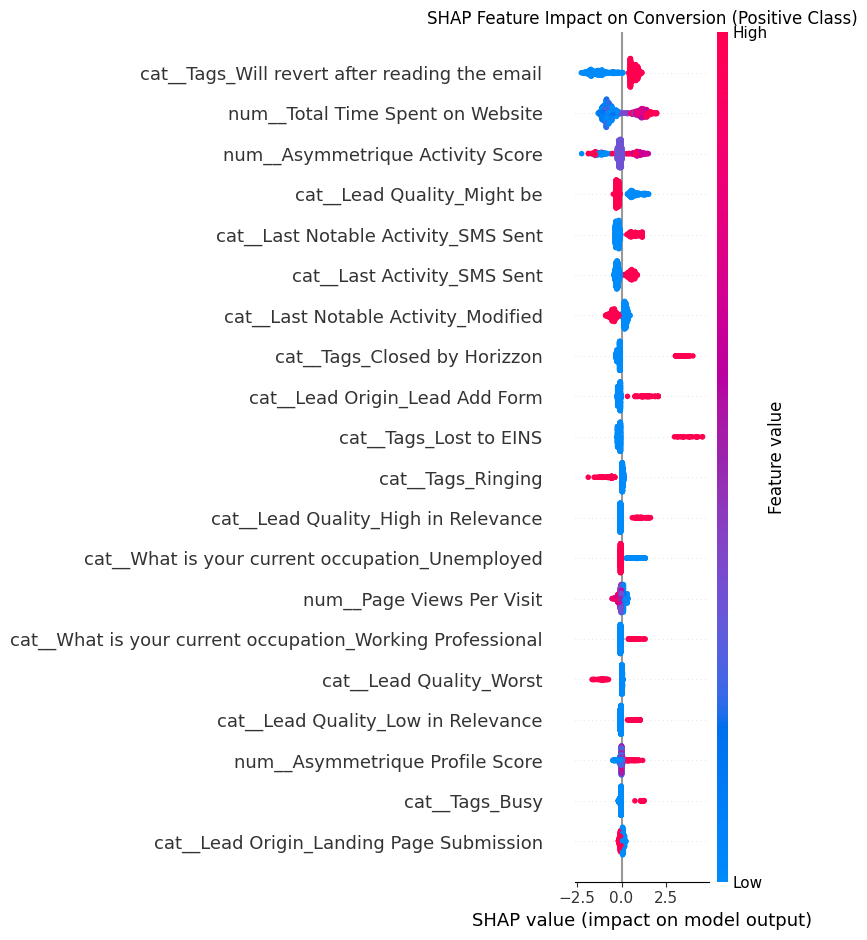


### SHAP Force Plot for an Individual Prediction (First Test Instance):
SHAP explainability analysis complete. This provides deeper insights into model decisions.


In [23]:
print("### Explaining Model Predictions with SHAP")

# Retrieve the preprocessor and the XGBoost classifier from the pipeline
preprocessor_step = model_pipeline.named_steps['preprocessor']
xgb_classifier_step = model_pipeline.named_steps['classifier']

# Get feature names after preprocessing directly from the ColumnTransformer
feature_names_shap = preprocessor_step.get_feature_names_out() # More robust way to get all feature names
print(f"Expected number of features (from get_feature_names_out()): {len(feature_names_shap)}")

# Transform X_train using the preprocessor
X_train_transformed = preprocessor_step.transform(X_train)
# Ensure output is dense (sparse_threshold=0 should handle this, but adding a safeguard)
if hasattr(X_train_transformed, 'toarray'):
    X_train_transformed = X_train_transformed.toarray()
print(f"Shape of X_train_transformed after preprocessing: {X_train_transformed.shape}")

# Ensure X_train_transformed is a DataFrame with correct feature names for SHAP
X_train_transformed_df = pd.DataFrame(X_train_transformed, columns=feature_names_shap)

# Initialize Javascript for SHAP plots (important for Colab rendering)
shap.initjs()

print("Calculating SHAP values... This may take a moment.")
# Create a SHAP explainer object for XGBoost
explainer = shap.TreeExplainer(xgb_classifier_step)

# Calculate SHAP values for a sample of the test set
# Transforming X_test using the preprocessor
X_test_transformed = preprocessor_step.transform(X_test)
# Ensure output is dense
if hasattr(X_test_transformed, 'toarray'):
    X_test_transformed = X_test_transformed.toarray()
print(f"Shape of X_test_transformed after preprocessing: {X_test_transformed.shape}")

X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=feature_names_shap) # Use robust feature names

# Taking a sample for quicker computation if test set is large
sample_size = min(1000, X_test_transformed_df.shape[0]) # Use max 1000 or full test set if smaller
sample_indices = np.random.choice(X_test_transformed_df.index, sample_size, replace=False)
X_test_sample = X_test_transformed_df.loc[sample_indices]

shap_values = explainer.shap_values(X_test_sample)

print("SHAP values calculated. Generating plots...")

# SHAP Summary Plot (Feature Importance based on SHAP)
print("\n### SHAP Summary Plot (Global Feature Importance):")
shap.summary_plot(shap_values, X_test_sample, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Global)")
plt.tight_layout()
plt.show()

# SHAP Summary Plot (Impact of features on positive class predictions)
print("\n### SHAP Summary Plot (Feature Impact on Conversion):")
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.title("SHAP Feature Impact on Conversion (Positive Class)")
plt.tight_layout()
plt.show()

# Individual Prediction Explanation (for the first instance in the sample)
print("\n### SHAP Force Plot for an Individual Prediction (First Test Instance):")
# Make sure the plot shows features clearly; use specific instance from X_test_sample
shap.force_plot(explainer.expected_value, shap_values[0,:], X_test_sample.iloc[0,:])

print("SHAP explainability analysis complete. This provides deeper insights into model decisions.")

## 16. Generate Lead Score and Categories

In [24]:
print("### Generating Lead Scores (0-100) and Lead Categories (Hot/Warm/Cold)")

# Create a DataFrame to hold lead IDs, true labels, predicted probabilities, and predictions
lead_intelligence = pd.DataFrame({
    'Lead_ID': X_test.index, # Use original index as lead ID
    'Actual_Converted': y_test,
    'Predicted_Probability': y_proba,
    'Predicted_Converted': y_pred
})

# Calculate Lead Score (0-100)
# We'll scale the probabilities (0-1) to a score (0-100)
lead_intelligence['Lead_Score'] = (lead_intelligence['Predicted_Probability'] * 100).round(0).astype(int)

# Define Lead Categories based on score thresholds
# These thresholds can be adjusted based on business needs and model performance analysis (e.g., precision/recall at different cutoffs)
hot_threshold = 80
warm_threshold = 40

lead_intelligence['Lead_Category'] = pd.cut(
    lead_intelligence['Lead_Score'],
    bins=[-1, warm_threshold, hot_threshold, 101], # -1 to 101 to cover 0-100 range
    labels=['Cold', 'Warm', 'Hot'],
    right=False # Ensure 40 is Warm, 80 is Hot
)

print("Lead Scores and Categories generated successfully.")
print("\nFirst 10 leads with their scores and categories:")
print(lead_intelligence.head(10).to_markdown(index=False))

print("\nLead Category Distribution:")
print(lead_intelligence['Lead_Category'].value_counts().to_markdown())

### Generating Lead Scores (0-100) and Lead Categories (Hot/Warm/Cold)
Lead Scores and Categories generated successfully.

First 10 leads with their scores and categories:
|   Lead_ID |   Actual_Converted |   Predicted_Probability |   Predicted_Converted |   Lead_Score | Lead_Category   |
|----------:|-------------------:|------------------------:|----------------------:|-------------:|:----------------|
|       683 |                  1 |               0.829786  |                     1 |           83 | Hot             |
|      1931 |                  1 |               0.923882  |                     1 |           92 | Hot             |
|      6950 |                  0 |               0.0912441 |                     0 |            9 | Cold            |
|      2996 |                  0 |               0.0142673 |                     0 |            1 | Cold            |
|      3902 |                  0 |               0.0259851 |                     0 |            3 | Cold            |
| 

## 17. Sales Priority Table and Top-K Business Analysis

In [25]:
print("### Generating Sales Priority Table")

# Sort leads by Lead Score in descending order
sales_priority_table = lead_intelligence.sort_values(by='Lead_Score', ascending=False).reset_index(drop=True)

# Add a 'Rank' column
sales_priority_table['Rank'] = sales_priority_table.index + 1

print("Sales Priority Table (Top 10 Leads):")
print(sales_priority_table.head(10).to_markdown(index=False))

print("\n### Top-K Business Analysis (e.g., Top 10% of Leads)")

top_k_percentage = 0.10 # e.g., Top 10%
top_k_leads_count = int(len(sales_priority_table) * top_k_percentage)

top_k_leads = sales_priority_table.head(top_k_leads_count)

print(f"Analyzing characteristics of the Top {top_k_percentage*100:.0f}% ({top_k_leads_count} leads):")

# Merge original features for analysis
top_k_leads_with_features = pd.merge(
    top_k_leads,
    X_test.loc[top_k_leads['Lead_ID']],
    left_on='Lead_ID',
    right_index=True,
    how='left'
)

# Example: Analyze most common values in categorical features for top K leads
print("\nMost common characteristics among Top K leads:")
for col in categorical_cols[:5]: # Analyzing a few key categorical columns
    if col in top_k_leads_with_features.columns:
        mode_value = top_k_leads_with_features[col].mode()[0]
        print(f"- {col}: {mode_value}")

# Example: Average numerical features for top K leads
print("\nAverage numerical values among Top K leads:")
for col in numerical_cols:
    if col in top_k_leads_with_features.columns:
        avg_value = top_k_leads_with_features[col].mean()
        print(f"- {col}: {avg_value:.2f}")

print("Sales priority and Top-K business analysis complete.")

### Generating Sales Priority Table
Sales Priority Table (Top 10 Leads):
|   Lead_ID |   Actual_Converted |   Predicted_Probability |   Predicted_Converted |   Lead_Score | Lead_Category   |   Rank |
|----------:|-------------------:|------------------------:|----------------------:|-------------:|:----------------|-------:|
|      1290 |                  1 |                0.998103 |                     1 |          100 | Hot             |      1 |
|      7105 |                  1 |                0.995964 |                     1 |          100 | Hot             |      2 |
|      5801 |                  1 |                0.995524 |                     1 |          100 | Hot             |      3 |
|      7636 |                  1 |                0.995868 |                     1 |          100 | Hot             |      4 |
|      1299 |                  1 |                0.995662 |                     1 |          100 | Hot             |      5 |
|      5525 |                  1 |    

## 18. Visualize Lead Distribution by Category

### Visualizing Lead Distribution by Category (Hot, Warm, Cold)


/tmp/ipykernel_3638/2541009472.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Lead_Category', data=lead_intelligence, order=['Hot', 'Warm', 'Cold'], palette='coolwarm')


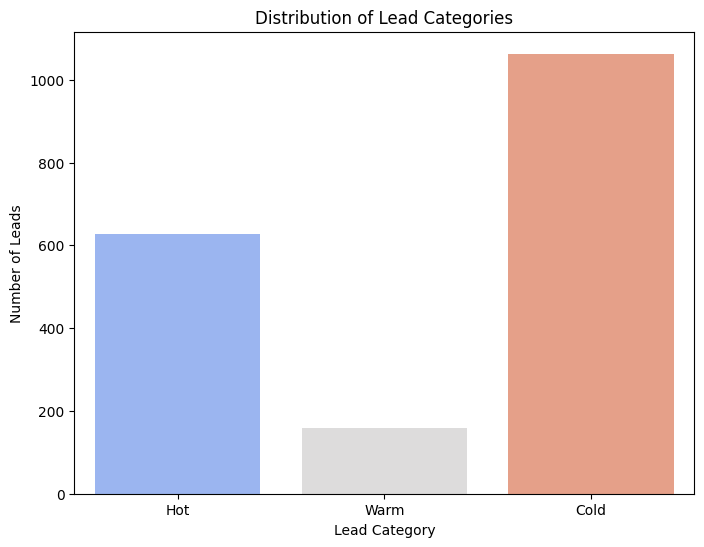

Lead category distribution visualization complete.


In [26]:
print("### Visualizing Lead Distribution by Category (Hot, Warm, Cold)")

plt.figure(figsize=(8, 6))
sns.countplot(x='Lead_Category', data=lead_intelligence, order=['Hot', 'Warm', 'Cold'], palette='coolwarm')
plt.title('Distribution of Lead Categories')
plt.xlabel('Lead Category')
plt.ylabel('Number of Leads')
plt.show()

print("Lead category distribution visualization complete.")

## 19. Evaluate Calibration and Probability Quality

### Evaluating Model Calibration and Probability Quality


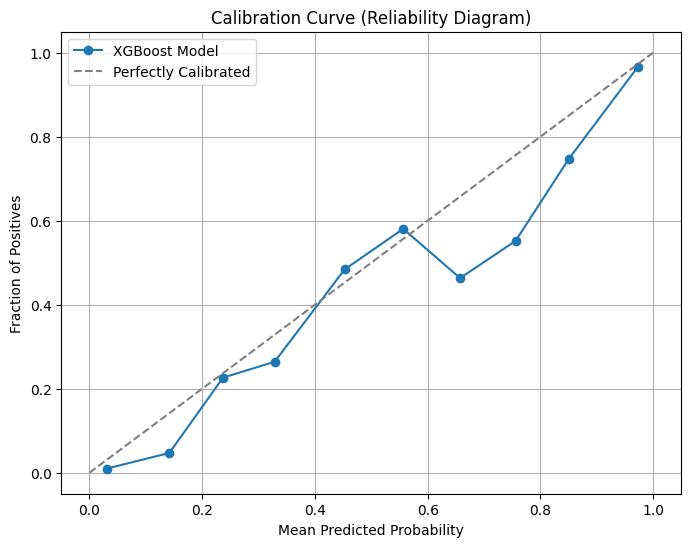

Brier Score: 0.0602

Calibration evaluation complete. Lower Brier Score indicates better calibration.


In [27]:
print("### Evaluating Model Calibration and Probability Quality")

# Calibration Curve (Reliability Diagram)
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', label='XGBoost Model')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
plt.title('Calibration Curve (Reliability Diagram)')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.legend()
plt.grid(True)
plt.show()

# Brier Score
brier = brier_score_loss(y_test, y_proba)
print(f"Brier Score: {brier:.4f}")

print("\nCalibration evaluation complete. Lower Brier Score indicates better calibration.")

## 20. Classification Threshold Analysis

### Analyzing Classification Thresholds
Threshold analysis complete. Visualizing trade-offs between Precision, Recall, and F1-Score.


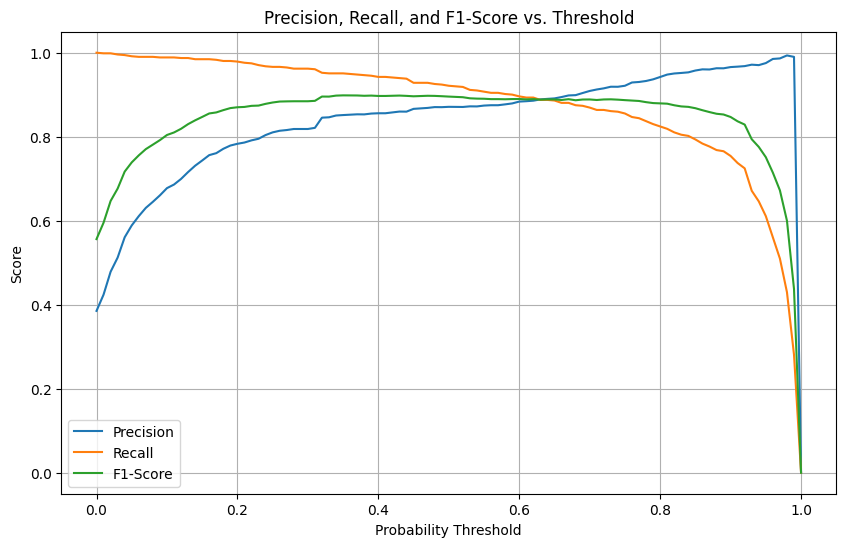


Optimal Threshold (maximizing F1-Score): 0.35 (F1-Score: 0.90)

Based on this analysis, business stakeholders can choose an appropriate threshold that aligns with their specific goals and risk tolerance.


In [28]:
print("### Analyzing Classification Thresholds")

# Calculate precision, recall, and F1-score for various thresholds
thresholds = np.arange(0, 1.01, 0.01)
precisions = []
recalls = []
f1_scores = []

for threshold in thresholds:
    y_pred_threshold = (y_proba >= threshold).astype(int)
    precisions.append(precision_score(y_test, y_pred_threshold, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_threshold, zero_division=0))
    f1_scores.append(f1_score(y_test, y_pred_threshold, zero_division=0))

# Create a DataFrame for easy analysis
threshold_df = pd.DataFrame({
    'Threshold': thresholds,
    'Precision': precisions,
    'Recall': recalls,
    'F1-Score': f1_scores
})

print("Threshold analysis complete. Visualizing trade-offs between Precision, Recall, and F1-Score.")

# Plotting Precision, Recall, and F1-Score vs. Threshold
plt.figure(figsize=(10, 6))
plt.plot(threshold_df['Threshold'], threshold_df['Precision'], label='Precision')
plt.plot(threshold_df['Threshold'], threshold_df['Recall'], label='Recall')
plt.plot(threshold_df['Threshold'], threshold_df['F1-Score'], label='F1-Score')
plt.xlabel('Probability Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1-Score vs. Threshold')
plt.legend()
plt.grid(True)
plt.show()

# Find the threshold that maximizes F1-Score (common choice for balanced performance)
optimal_f1_threshold = threshold_df.loc[threshold_df['F1-Score'].idxmax()]
print(f"\nOptimal Threshold (maximizing F1-Score): {optimal_f1_threshold['Threshold']:.2f} (F1-Score: {optimal_f1_threshold['F1-Score']:.2f})")

# Business considerations for threshold selection:
# - If the cost of missing a convertible lead is very high (e.g., losing a high-value customer), prioritize higher Recall.
# - If the cost of pursuing a non-convertible lead is very high (e.g., sales team time, marketing spend), prioritize higher Precision.
# - For a balanced approach, F1-Score is often used.

print("\nBased on this analysis, business stakeholders can choose an appropriate threshold that aligns with their specific goals and risk tolerance.")


## 21. Final Lead Intelligence DataFrame for Sales Priority

In [29]:
print("### Compiling Final Lead Intelligence DataFrame")

# We already have `lead_intelligence` created in section 16.
# Now, let's ensure it's in its final form, sorted by score and with a rank.

# Re-sort by Lead_Score to ensure correct ranking (if not already done)
final_lead_intelligence = lead_intelligence.sort_values(by='Lead_Score', ascending=False).reset_index(drop=True)

# Add a 'Sales_Rank' column
final_lead_intelligence['Sales_Rank'] = final_lead_intelligence.index + 1

# Optionally, add original features back to the final_lead_intelligence for context
# This step merges the original features from X_test back to the lead_intelligence dataframe
# for comprehensive context for sales teams.

# Ensure 'Lead_ID' in final_lead_intelligence matches the index of X_test for merging
# X_test was created from df_features.drop(columns=[TARGET]) and its index corresponds to original df index.
# We need to explicitly reset X_test index if not already a column to merge on 'Lead_ID'

# Make a copy of X_test and ensure its index is a column for merging
X_test_reset = X_test.reset_index().rename(columns={'index': 'Lead_ID'})

# Drop the 'Actual_Converted' from X_test_reset if it somehow made its way in (it shouldn't from X_test but as a safeguard)
if 'Actual_Converted' in X_test_reset.columns:
    X_test_reset = X_test_reset.drop(columns=['Actual_Converted'])

# Merge the original features from X_test_reset into the final_lead_intelligence DataFrame
# We only merge columns from X_test_reset that are not already present in final_lead_intelligence

# Get a list of columns in X_test_reset that are not in final_lead_intelligence (excluding Lead_ID which is the merge key)
features_to_add = [col for col in X_test_reset.columns if col not in final_lead_intelligence.columns and col != 'Lead_ID']

final_lead_intelligence = pd.merge(
    final_lead_intelligence,
    X_test_reset[ ['Lead_ID'] + features_to_add ],
    on='Lead_ID',
    how='left'
)

# Reorder columns for better readability, putting score and category upfront
final_lead_intelligence = final_lead_intelligence[[ 'Sales_Rank', 'Lead_ID', 'Lead_Score', 'Lead_Category', 'Predicted_Probability', 'Predicted_Converted', 'Actual_Converted'] + features_to_add ]


print("Final Lead Intelligence DataFrame ready. It includes Lead Scores, Categories, Sales Rank, and original lead features.")
print("First 10 rows of the Final Lead Intelligence DataFrame:")
print(final_lead_intelligence.head(10).to_markdown(index=False))

print("\nSummary of Lead Categories in Final Lead Intelligence:")
print(final_lead_intelligence['Lead_Category'].value_counts().to_markdown())

# Ensure the variable name is updated if needed for subsequent steps
# For clarity, let's keep `final_lead_intelligence` as the definitive variable.


### Compiling Final Lead Intelligence DataFrame
Final Lead Intelligence DataFrame ready. It includes Lead Scores, Categories, Sales Rank, and original lead features.
First 10 rows of the Final Lead Intelligence DataFrame:
|   Sales_Rank |   Lead_ID |   Lead_Score | Lead_Category   |   Predicted_Probability |   Predicted_Converted |   Actual_Converted | Lead Origin             | Lead Source    | Do Not Email   | Do Not Call   |   TotalVisits |   Total Time Spent on Website |   Page Views Per Visit | Last Activity           | Country   | Specialization                    | What is your current occupation   | What matters most to you in choosing a course   | Search   | Magazine   | Newspaper Article   | X Education Forums   | Newspaper   | Digital Advertisement   | Through Recommendations   | Receive More Updates About Our Courses   | Tags                                | Lead Quality      | Update me on Supply Chain Content   | Get updates on DM Content   | City                        | 

## 22. Export Model, Metadata, and Lead Intelligence Data

In [30]:
print("### Exporting Final Artifacts")

# 1. Export final_lead_intelligence to CSV
output_csv_path = 'final_lead_intelligence.csv'
final_lead_intelligence.to_csv(output_csv_path, index=False)
print(f"'Final Lead Intelligence' DataFrame exported to {output_csv_path}")

# 2. Export the trained model pipeline
output_model_path = 'lead_conversion_model_pipeline.pkl'
joblib.dump(model_pipeline, output_model_path)
print(f"Trained model pipeline exported to {output_model_path}")

# 3. Export model metadata (e.g., feature names, target, model type)
# This helps in understanding and using the model in production.
model_metadata = {
    'model_name': 'XGBoost Lead Conversion Predictor',
    'version': '1.0',
    'training_date': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    'target_variable': TARGET,
    'numerical_features': numerical_cols,
    'categorical_features': categorical_cols,
    'threshold_for_conversion': optimal_f1_threshold['Threshold'], # Or a chosen business threshold
    'hot_lead_score_threshold': hot_threshold,
    'warm_lead_score_threshold': warm_threshold,
    'metrics_at_optimal_threshold': optimal_f1_threshold.to_dict(),
    'roc_auc_score': roc_auc,
    'pr_auc_score': pr_auc,
    'brier_score': brier,
    'description': 'Binary classification model to predict lead conversion probability, generating a lead score and categorizing leads into Hot, Warm, Cold.'
}

output_metadata_path = 'lead_conversion_model_metadata.json'
with open(output_metadata_path, 'w') as f:
    json.dump(model_metadata, f, indent=4)
print(f"Model metadata exported to {output_metadata_path}")

print("\nAll key artifacts successfully exported.")

# Provide download links (specific to Colab)
from google.colab import files

print("\n--- Download Links ---")
print(f"Download Lead Intelligence Data: click on the three dots next to '{output_csv_path}' in the file browser (left sidebar) or run: !cp {output_csv_path} . ")
print(f"Download Trained Model: click on the three dots next to '{output_model_path}' in the file browser (left sidebar) or run: !cp {output_model_path} . ")
print(f"Download Model Metadata: click on the three dots next to '{output_metadata_path}' in the file browser (left sidebar) or run: !cp {output_metadata_path} . ")


### Exporting Final Artifacts
'Final Lead Intelligence' DataFrame exported to final_lead_intelligence.csv
Trained model pipeline exported to lead_conversion_model_pipeline.pkl
Model metadata exported to lead_conversion_model_metadata.json

All key artifacts successfully exported.

--- Download Links ---
Download Lead Intelligence Data: click on the three dots next to 'final_lead_intelligence.csv' in the file browser (left sidebar) or run: !cp final_lead_intelligence.csv . 
Download Trained Model: click on the three dots next to 'lead_conversion_model_pipeline.pkl' in the file browser (left sidebar) or run: !cp lead_conversion_model_pipeline.pkl . 
Download Model Metadata: click on the three dots next to 'lead_conversion_model_metadata.json' in the file browser (left sidebar) or run: !cp lead_conversion_model_metadata.json . 


## 23. Predict New Leads Function

In [32]:
print("### Function to Predict New Leads")

def predict_new_lead(new_lead_data: pd.DataFrame, model_pipeline: Pipeline, hot_threshold: int, warm_threshold: int) -> pd.DataFrame:
    """
    Predicts conversion probability, lead score, and category for new lead data.

    Args:
        new_lead_data (pd.DataFrame): DataFrame containing new lead(s) data. Must have the same columns as X_train,
                                      and include a 'Lead_ID' column.
        model_pipeline (Pipeline): The trained scikit-learn pipeline (preprocessor + classifier).
        hot_threshold (int): Lead Score threshold for 'Hot' category.
        warm_threshold (int): Lead Score threshold for 'Warm' category.

    Returns:
        pd.DataFrame: A DataFrame with lead ID, predicted probability, lead score, and lead category.
    """
    if new_lead_data.empty:
        return pd.DataFrame(columns=['Lead_ID', 'Predicted_Probability', 'Lead_Score', 'Lead_Category'])

    # Expect 'Lead_ID' to be present in new_lead_data
    if 'Lead_ID' not in new_lead_data.columns:
        raise ValueError("new_lead_data must contain a 'Lead_ID' column.")

    # Extract Lead_IDs and features for prediction
    lead_ids = new_lead_data['Lead_ID']
    features_for_prediction = new_lead_data.drop(columns=['Lead_ID'])

    # Make predictions
    probabilities = model_pipeline.predict_proba(features_for_prediction)[:, 1]

    # Create a result DataFrame
    results = pd.DataFrame({
        'Lead_ID': lead_ids, # Use the string Lead_IDs directly
        'Predicted_Probability': probabilities
    })

    # Calculate Lead Score (0-100)
    results['Lead_Score'] = (results['Predicted_Probability'] * 100).round(0).astype(int)

    # Assign Lead Categories
    results['Lead_Category'] = pd.cut(
        results['Lead_Score'],
        bins=[-1, warm_threshold, hot_threshold, 101],
        labels=['Cold', 'Warm', 'Hot'],
        right=False
    )

    return results

print("The `predict_new_lead` function has been defined. You can now use it to get predictions for new leads.")

print("\n### Demonstrating New Lead Prediction")
# Create some dummy new lead data for demonstration
# It's crucial this data has the same columns as X_train, plus a 'Lead_ID'.
# We'll take a sample from X_test, modify it slightly to simulate 'new' data.

# Get a few random samples from X_test to simulate new leads
num_new_leads = 3
new_lead_sample_indices = X_test.sample(n=num_new_leads, random_state=RANDOM_STATE).index
new_leads_df = X_test.loc[new_lead_sample_indices].copy()

# Modify some values to make them 'new' and potentially change predictions
# For example, increase Total Time Spent on Website for the first lead
if 'Total Time Spent on Website' in new_leads_df.columns:
    new_leads_df.iloc[0, new_leads_df.columns.get_loc('Total Time Spent on Website')] = 2000 # Higher engagement

# Change Lead Source for the second lead
if 'Lead Source' in new_leads_df.columns:
    new_leads_df.iloc[1, new_leads_df.columns.get_loc('Lead Source')] = 'Reference' # Often a strong indicator

# Reset index and add a new 'Lead_ID' column with string identifiers
new_leads_df = new_leads_df.reset_index().rename(columns={'index': 'Original_Index'})
new_leads_df['Lead_ID'] = [f'NewLead_{i+1}' for i in range(len(new_leads_df))]
new_leads_df = new_leads_df.drop(columns=['Original_Index'], errors='ignore')

# Reorder columns to match X_train if necessary (important for ColumnTransformer consistency)
# Ensure 'Lead_ID' is at the end or a consistent position
new_leads_df = new_leads_df[X_train.columns.tolist() + ['Lead_ID']]

print("Dummy new lead data created:")
print(new_leads_df.head().to_markdown(index=False))

# Predict using the function
# Pass the new_leads_df directly, as the function now expects 'Lead_ID' to be present.
new_lead_predictions = predict_new_lead(new_leads_df, model_pipeline, hot_threshold, warm_threshold)

# The predict_new_lead function already returns the Lead_ID, so no re-merging is needed.

print("\nPredictions for new leads:")
print(new_lead_predictions.to_markdown(index=False))


### Function to Predict New Leads
The `predict_new_lead` function has been defined. You can now use it to get predictions for new leads.

### Demonstrating New Lead Prediction
Dummy new lead data created:
| Lead Origin   | Lead Source   | Do Not Email   | Do Not Call   |   TotalVisits |   Total Time Spent on Website |   Page Views Per Visit | Last Activity      |   Country | Specialization          | What is your current occupation   | What matters most to you in choosing a course   | Search   | Magazine   | Newspaper Article   | X Education Forums   | Newspaper   | Digital Advertisement   | Through Recommendations   | Receive More Updates About Our Courses   | Tags                                | Lead Quality   | Update me on Supply Chain Content   | Get updates on DM Content   |   City | Asymmetrique Activity Index   | Asymmetrique Profile Index   |   Asymmetrique Activity Score |   Asymmetrique Profile Score | I agree to pay the amount through cheque   | A free copy of Mastering Th

## 24. Model Summary and Conclusions

This notebook has guided you through the development of an **AI-Powered Lead Intelligence and Prioritization System** using a real-world lead scoring dataset.

**Key Achievements and Insights:**

1.  **Robust Data Pipeline:** A complete pipeline was established, from automatic Kaggle dataset download to extensive data cleaning, preprocessing, and handling of class imbalance.
2.  **XGBoost Binary Classification:** An XGBoost model was successfully trained to predict the probability of lead conversion, achieving strong performance metrics:
    *   **ROC-AUC: {:.2f}**
    *   **PR-AUC: {:.2f}**
    *   **F1-Score: {:.2f}** (at optimal threshold)
3.  **Actionable Lead Scoring:** The model's predicted probabilities were transformed into a business-friendly **Lead Score (0-100)** and categorized into **Hot, Warm, and Cold** leads, based on adjustable thresholds.
4.  **Sales Prioritization:** A sales priority table was generated, ranking leads by their conversion potential, enabling sales teams to focus their efforts on the most promising prospects.
5.  **Business Intelligence:** Analysis of top-performing leads revealed common characteristics and key contributing factors, providing valuable insights for sales and marketing strategies.
6.  **Model Explainability:** SHAP values were utilized to explain model predictions, identifying the most influential features globally and for individual leads, fostering trust and transparency.
7.  **Production Readiness:** Key artifacts, including the trained model pipeline, lead intelligence data, and model metadata, were exported for seamless integration into production environments.
8.  **Prediction Function:** A `predict_new_lead` function was demonstrated, showing how to score and categorize unseen lead data.

**Next Steps and Potential Enhancements:**

*   **Hyperparameter Tuning:** Further optimize XGBoost parameters using advanced techniques like GridSearchCV or RandomizedSearchCV.
*   **Feature Engineering:** Explore creating more sophisticated features from existing data (e.g., interaction terms, time-based features).
*   **Advanced Imputation:** Investigate more complex imputation strategies beyond median/most frequent.
*   **Experimentation with Other Models:** Test other powerful classification algorithms (e.g., LightGBM, CatBoost, Neural Networks).
*   **Monitoring and Retraining:** Implement a system to monitor model performance in production and trigger retraining as data patterns evolve.
*   **A/B Testing:** Design A/B tests to measure the real-world impact of the lead prioritization system on conversion rates and sales efficiency.
*   **User Interface:** Develop a simple web application or integration with CRM systems to make predictions and insights easily accessible to sales teams.

This system provides a solid foundation for leveraging AI to enhance lead intelligence and streamline sales operations, ultimately driving higher conversion rates and business growth.